In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score


np.random.seed(42)

In [2]:
# Gaussian Mixture Model Parameters
# Pis
pi = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

# Means
means = [
    [-10.0, 0.0],
    [0.0, -10.0],
    [10.0, 0.0],
    [0.0, 10.0],
    [-5.0, 4.5],
    [5.0, 4.5],
    [0.0, -0.5],
    [0.0, -7.5],
    [-7.0, -5.5],
    [7.0, -5.5],
]

# Sigmas
covs = [
    [[0.1, 0.0], [0.0, 15.0]],
    [[15.0, 0.0], [0.0, 0.1]],
    [[0.1, 0.0], [0.0, 15.0]],
    [[15.0, 0.0], [0.0, 0.1]],
    [[3.0, 0.0], [0.0, 0.1]],
    [[1.0, 0.0], [0.0, 1.0]],
    [[0.1, 0.0], [0.0, 3.0]],
    [[4.0, 0.0], [0.0, 0.1]],
    [[0.5500000000000002, -0.45], [-0.45, 0.5499999999999999]],
    [[0.5500000000000002, 0.45], [0.45, 0.5499999999999999]],
]

In [3]:
# Generate synthetic data from the GMM
def generate_data(n_samples=1000):
    data = []
    labels = []
    for i, (mean, cov) in enumerate(zip(means, covs)):
        n = int(n_samples * pi[i])
        samples = np.random.multivariate_normal(mean, cov, n)
        data.append(samples)
        labels.extend([i] * n)
    return np.vstack(data), np.array(labels)


data, labels = generate_data()

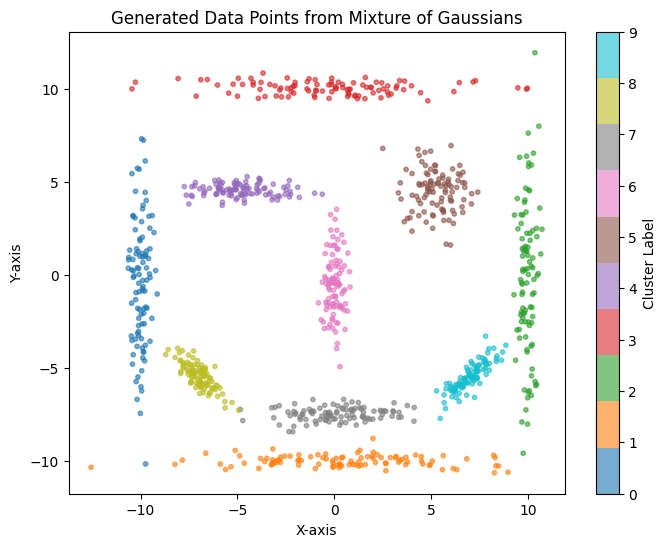

In [4]:
# Visualize the true distribution
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, c=labels, cmap="tab10", s=10)
plt.title("Generated Data Points from Mixture of Gaussians")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.colorbar(label="Cluster Label")

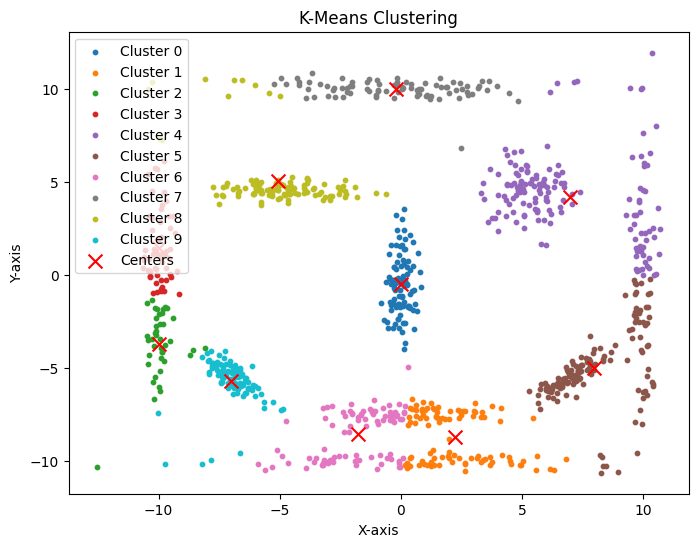

K-Means ARI: 0.67


In [5]:
# 1. K-Means Clustering
def run_kmeans(data, n_clusters=3, max_iter=400, tol=1e-4):
    # Random initialization of cluster centers
    centers = data[np.random.choice(len(data), n_clusters, replace=False)]
    predictions = np.zeros(len(data))
    
    for iteration in range(max_iter):
        # Step 1: Assign points to the nearest cluster center
        distances = np.linalg.norm(data[:, np.newaxis] - centers, axis=2)
        new_predictions = np.argmin(distances, axis=1)

        # Step 2: Compute new cluster centers
        new_centers = np.array([data[new_predictions == i].mean(axis=0) for i in range(n_clusters)])
        
        # Check for convergence
        if np.all(predictions == new_predictions) and np.allclose(centers, new_centers, atol=tol):
            break

        predictions = new_predictions
        centers = new_centers

    return predictions, centers

n_clusters = len(pi)
kmeans_predictions, centers = run_kmeans(data, n_clusters)

# Plot K-Means Results
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(
        data[kmeans_predictions == i, 0],
        data[kmeans_predictions == i, 1],
        label=f"Cluster {i}",
        s=10
    )
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="x", s=100, label="Centers")
plt.legend()
plt.title("K-Means Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# Compute ARI
kmeans_ari = adjusted_rand_score(labels, kmeans_predictions)
print(f"K-Means ARI: {kmeans_ari:.2f}")


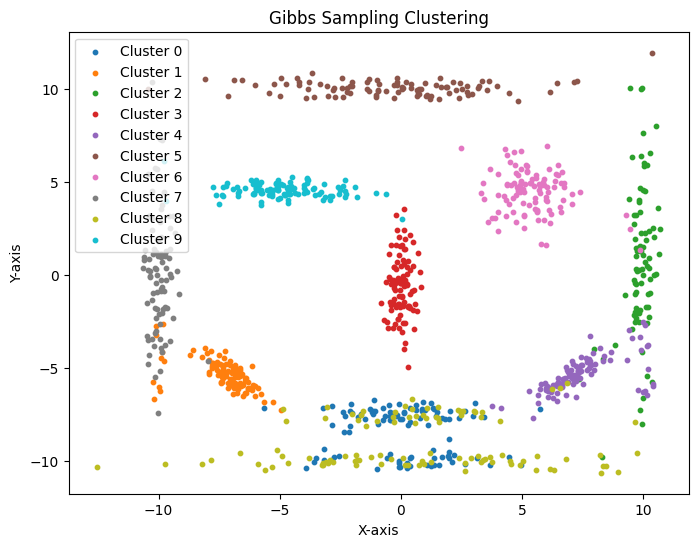

Gibbs Sampling ARI: 0.79


In [6]:
# 2. Gibbs Sampling for Clustering
from scipy.stats import multivariate_normal

def gibbs_sampling(data, n_clusters=3, n_samples=500, burn_in=200):
    n_points, dim = data.shape
    cluster_assignments = np.random.choice(n_clusters, n_points)
    cluster_means = np.random.randn(n_clusters, dim)
    cluster_covariances = [np.eye(dim) for _ in range(n_clusters)]
    
    for sample in range(n_samples + burn_in):
        # Update cluster parameters
        for k in range(n_clusters):
            points_in_cluster = data[cluster_assignments == k]
            if len(points_in_cluster) > 0:
                cluster_means[k] = points_in_cluster.mean(axis=0)
                cluster_covariances[k] = np.cov(points_in_cluster, rowvar=False) + np.eye(dim)

        # Update cluster assignments
        for i in range(n_points):
            posterior_probs = []
            for k in range(n_clusters):
                prob = multivariate_normal.pdf(data[i], mean=cluster_means[k], cov=cluster_covariances[k])
                posterior_probs.append(prob)
            posterior_probs = np.array(posterior_probs)
            posterior_probs /= posterior_probs.sum()
            cluster_assignments[i] = np.random.choice(n_clusters, p=posterior_probs)
    
    return cluster_assignments

gibbs_predictions = gibbs_sampling(data, n_clusters=len(pi))

# Plot Gibbs Sampling Results
plt.figure(figsize=(8, 6))
for i in range(len(pi)):
    plt.scatter(
        data[gibbs_predictions == i, 0],
        data[gibbs_predictions == i, 1],
        label=f"Cluster {i}",
        s=10
    )
plt.title("Gibbs Sampling Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

# Compute ARI
gibbs_ari = adjusted_rand_score(labels, gibbs_predictions)
print(f"Gibbs Sampling ARI: {gibbs_ari:.2f}")


Running Metropolis-Hastings with proposal variance σ² = 0.01


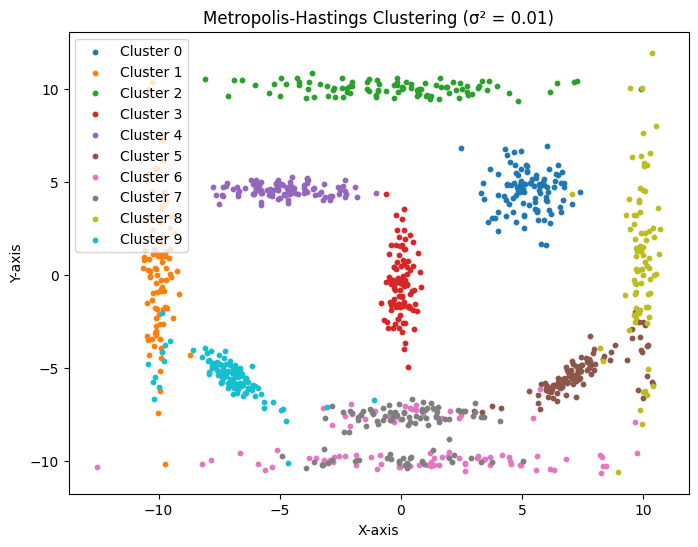

Running Metropolis-Hastings with proposal variance σ² = 0.1


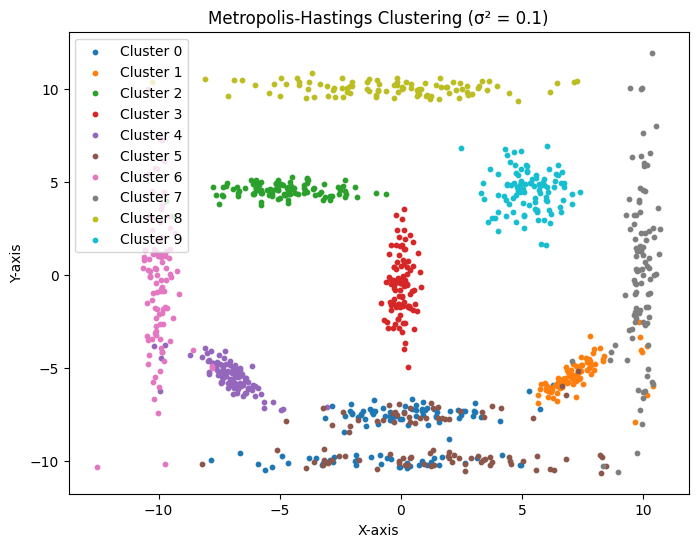

Running Metropolis-Hastings with proposal variance σ² = 1


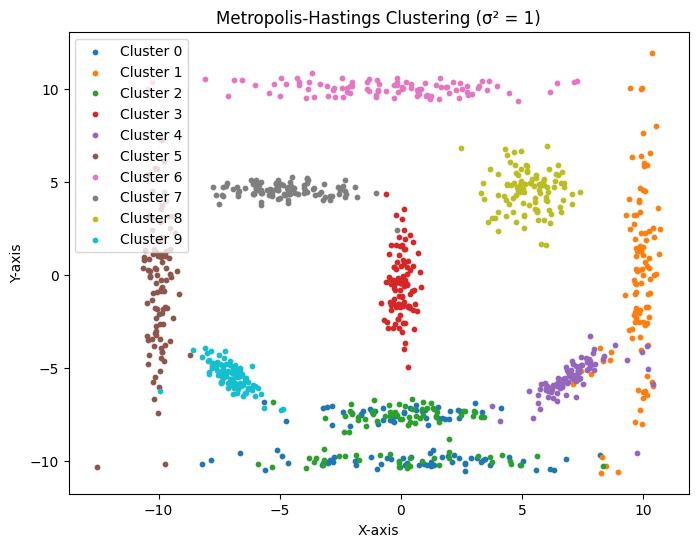

Running Metropolis-Hastings with proposal variance σ² = 10


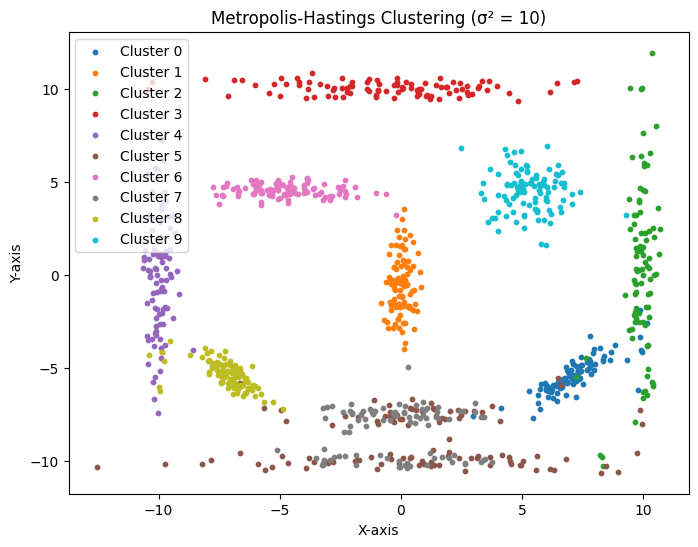

In [7]:
# 3. Metropolis-Hastings for Clustering
from scipy.stats import multivariate_normal

def metropolis_hastings(
    data, n_clusters=3, proposal_std=1.0, n_samples=500, burn_in=200
):
    """
    Perform clustering using the Metropolis-Hastings algorithm with Gaussian proposals.
    
    Parameters:
        data: ndarray of shape (n_points, n_features)
        n_clusters: Number of clusters
        proposal_std: Standard deviation for Gaussian proposal
        n_samples: Number of samples to collect after burn-in
        burn_in: Number of burn-in iterations
    
    Returns:
        cluster_assignments: Final cluster assignments after sampling
    """
    n_points, dim = data.shape
    cluster_assignments = np.random.choice(n_clusters, n_points)
    cluster_means = np.random.randn(n_clusters, dim)
    cluster_covariances = [np.eye(dim) for _ in range(n_clusters)]
    
    def posterior_probability(point, cluster_idx):
        """Compute the posterior probability for a data point belonging to a cluster."""
        return multivariate_normal.pdf(point, mean=cluster_means[cluster_idx], cov=cluster_covariances[cluster_idx])
    
    for sample in range(n_samples + burn_in):
        # Update cluster parameters
        for k in range(n_clusters):
            points_in_cluster = data[cluster_assignments == k]
            if len(points_in_cluster) > 0:
                cluster_means[k] = points_in_cluster.mean(axis=0)
                cluster_covariances[k] = np.cov(points_in_cluster, rowvar=False) + np.eye(dim)
        
        # Update cluster assignments
        for i in range(n_points):
            current_cluster = cluster_assignments[i]
            proposed_cluster = np.random.choice(n_clusters)
            
            current_prob = posterior_probability(data[i], current_cluster)
            proposed_prob = posterior_probability(data[i], proposed_cluster)
            
            acceptance_ratio = min(1, proposed_prob / (current_prob + 1e-9))
            
            if np.random.rand() < acceptance_ratio:
                cluster_assignments[i] = proposed_cluster
    
    return cluster_assignments


# Define the proposal variances to explore
proposal_variances = [0.01, 0.1, 1, 10]

for proposal_variance in proposal_variances:
    print(f"Running Metropolis-Hastings with proposal variance σ² = {proposal_variance}")
    mh_predictions = metropolis_hastings(
        data, n_clusters=len(pi), proposal_std=proposal_variance
    )
    
    # Visualize clustering results
    plt.figure(figsize=(8, 6))
    for i in range(len(pi)):
        plt.scatter(
            data[mh_predictions == i, 0],
            data[mh_predictions == i, 1],
            label=f"Cluster {i}",
            s=10
        )
    plt.title(f"Metropolis-Hastings Clustering (σ² = {proposal_variance})")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.legend()
    plt.show()
    
    



In [8]:
# Evaluate Clustering Results

# Assuming true_labels is a numpy array containing the true labels of the data points
# and kmeans_predictions, gibbs_predictions, mh_predictions are the predicted labels

# Calculate ARI for each clustering method
kmeans_ari = adjusted_rand_score(labels, kmeans_predictions)
gibbs_ari = adjusted_rand_score(labels, gibbs_predictions)
mh_ari = adjusted_rand_score(labels, mh_predictions)

# Print the ARI results
print("Adjusted Rand Index of Clustering Methods:")
print(f"K-Means ARI: {kmeans_ari:.2f}")
print(f"Gibbs Sampling ARI: {gibbs_ari:.2f}")
# Metropolis-Hastings
proposal_variances = [0.01, 0.1, 1, 10]
for proposal_variance in proposal_variances:
    # Run Metropolis-Hastings for each proposal variance
    mh_predictions = metropolis_hastings(data, n_clusters=len(pi), proposal_std=proposal_variance)
    mh_ari = adjusted_rand_score(labels, mh_predictions)
    print(f"Metropolis-Hastings ARI (σ² = {proposal_variance}): {mh_ari:.2f}")


Adjusted Rand Index of Clustering Methods:
K-Means ARI: 0.67
Gibbs Sampling ARI: 0.79
Metropolis-Hastings ARI (σ² = 0.01): 0.80
Metropolis-Hastings ARI (σ² = 0.1): 0.82
Metropolis-Hastings ARI (σ² = 1): 0.78
Metropolis-Hastings ARI (σ² = 10): 0.79


In [9]:
# Compare Results
print("Comparison of Clustering Results:")
print("K-Means Predictions:", np.bincount(kmeans_predictions))
print("Gibbs Sampling Predictions:", np.bincount(gibbs_predictions))
# Metropolis-Hastings for all σ² values
proposal_variances = [0.01, 0.1, 1, 10]
for proposal_variance in proposal_variances:
    print(f"\nMetropolis-Hastings Predictions (σ² = {proposal_variance}):")
    mh_predictions = metropolis_hastings(data, n_clusters=len(pi), proposal_std=proposal_variance)
    print(np.bincount(mh_predictions))

Comparison of Clustering Results:
K-Means Predictions: [ 99  99  41  59 158 153  92  85 111 103]
Gibbs Sampling Predictions: [103 108  86  99 110  97 103  89 102 103]

Metropolis-Hastings Predictions (σ² = 0.01):
[106 102  96  95  97 105  94 100 105 100]

Metropolis-Hastings Predictions (σ² = 0.1):
[100 123  83  99 105 100  93  99 108  90]

Metropolis-Hastings Predictions (σ² = 1):
[100  97 112 100 101  90 104 100 100  96]

Metropolis-Hastings Predictions (σ² = 10):
[102 105 101  99 109  97  95  96  94 102]
